# Project KALM: Kalman-based Adaptive Linear Modeling

**Objective:** Use a Kalman filter to estimate a clean, time-varying random signal from noisy measurements.

This notebook leverages **PySDR** for noise generation and analysis.


## 1. Import Required Libraries

In [34]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Custom utils
import sys
sys.path.append('../src')
from utils import *

## 2. Simulate Time-Varying Noisy Signal

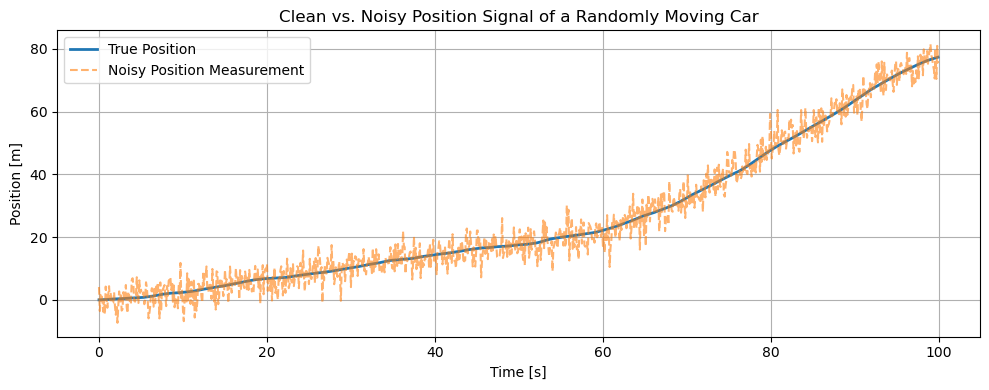

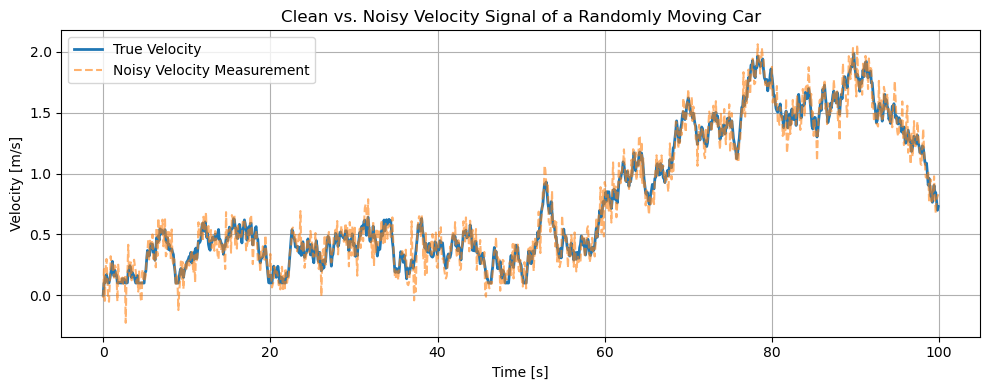

In [36]:
# Time setup
dt = 0.1        # Time step [s]
T = 100         # Total simulation time [s]
N = int(T / dt)
np.random.seed(69)

# Time vector
time = np.arange(N) * dt

# Parameters for realistic car dynamics
max_acc = 1      # Maximum acceleration [m/s²]
min_acc = -1     # Maximum braking [m/s²]
max_speed = 10     # Max speed [m/s]
min_speed = 0.1      # No reverse for simplicity

# Generate bounded random acceleration profile
acc_profile = np.random.uniform(min_acc, max_acc, N)

# Integrate acceleration to get velocity (with speed limits)
vel_true = np.zeros(N)
for i in range(1, N):
    vel_true[i] = vel_true[i-1] + acc_profile[i] * dt
    vel_true[i] = np.clip(vel_true[i], min_speed, max_speed)

# Integrate velocity to get position
pos_true = np.cumsum(vel_true * dt)

# Add realistic noise
snr_db_pos = 20
snr_db_vel = 20
pos_meas = add_awgn_noise(pos_true, snr_db_pos)
vel_meas = add_awgn_noise(vel_true, snr_db_vel)

# Plot Position
plt.figure(figsize=(10, 4))
plt.plot(time, pos_true, label='True Position', linewidth=2)
plt.plot(time, pos_meas, label='Noisy Position Measurement', linestyle='--', alpha=0.6)
plt.title('Clean vs. Noisy Position Signal of a Randomly Moving Car')
plt.xlabel('Time [s]')
plt.ylabel('Position [m]')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Plot Velocity
plt.figure(figsize=(10, 4))
plt.plot(time, vel_true, label='True Velocity', linewidth=2)
plt.plot(time, vel_meas, label='Noisy Velocity Measurement', linestyle='--', alpha=0.6)
plt.title('Clean vs. Noisy Velocity Signal of a Randomly Moving Car')
plt.xlabel('Time [s]')
plt.ylabel('Velocity [m/s]')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## 3. Implement Kalman Filter

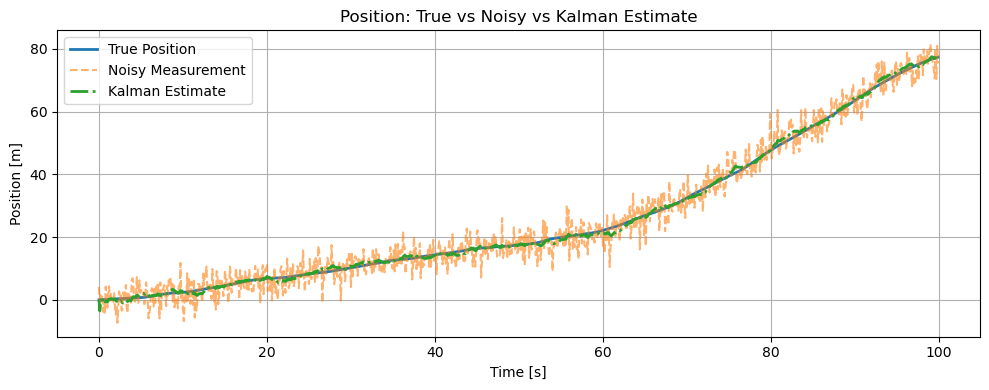

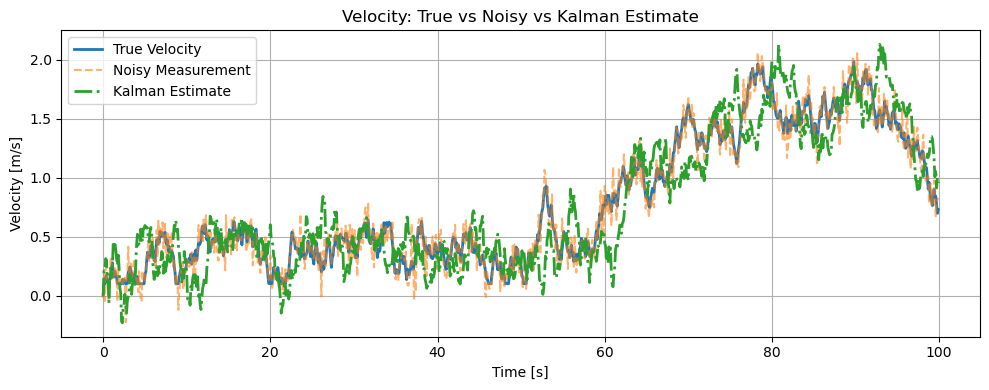

In [ ]:
# TODO: Implement a simple Kalman filter for 1D tracking


# Initialize Kalman filter
x_est = np.zeros((2, N))  # [position; velocity]
P = np.diag([1.0, 1.0])  

# System model
F = np.array([[1, dt],
              [0, 1]])  # State transition
H = np.eye(2)           # Measurement matrix
q = 1e-4  # Process Noise Variance
Q = np.array([[q, 0],
              [0, q]])

R = np.array([[0.001, 0],
              [0, 0.001]])  # Measurement noise covariance

for k in range(1, N):
    # Predict step
    x_pred = F @ x_est[:, k-1]
    P_pred = F @ P @ F.T + Q

    # Measurement at step k
    z = np.array([pos_meas[k], vel_meas[k]])

    # Update step
    y = z - (H @ x_pred)               # Innovation
    S = H @ P_pred @ H.T + R           # Innovation covariance
    K = P_pred @ H.T @ np.linalg.inv(S)  # Kalman gain
    x_est[:, k] = x_pred + K @ y
    P = (np.eye(2) - K @ H) @ P_pred


plt.figure(figsize=(10, 4))
plt.plot(time, pos_true, label='True Position', linewidth=2)
plt.plot(time, pos_meas, label='Noisy Measurement', linestyle='--', alpha=0.6)
plt.plot(time, x_est[0], label='Kalman Estimate', linestyle='-.', linewidth=2)
plt.title('Position: True vs Noisy vs Kalman Estimate')
plt.xlabel('Time [s]')
plt.ylabel('Position [m]')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time, vel_true, label='True Velocity', linewidth=2)
plt.plot(time, vel_meas, label='Noisy Measurement', linestyle='--', alpha=0.6)
plt.plot(time, x_est[1], label='Kalman Estimate', linestyle='-.', linewidth=2)
plt.title('Velocity: True vs Noisy vs Kalman Estimate')
plt.xlabel('Time [s]')
plt.ylabel('Velocity [m/s]')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## 4. Error Convergence Visualization

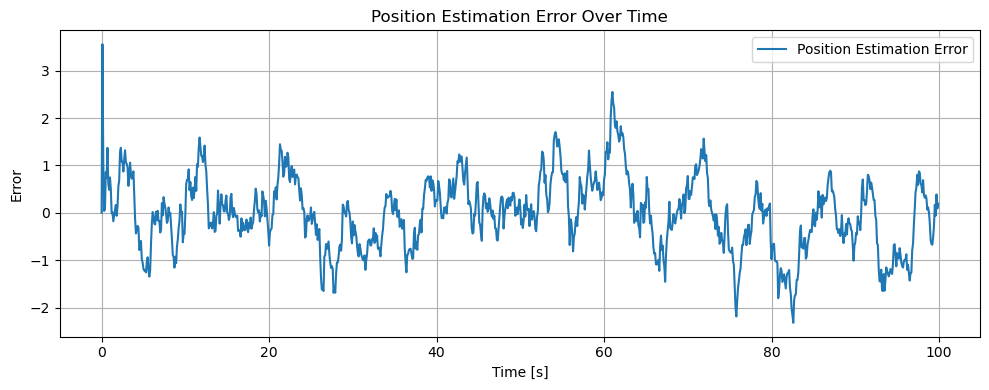

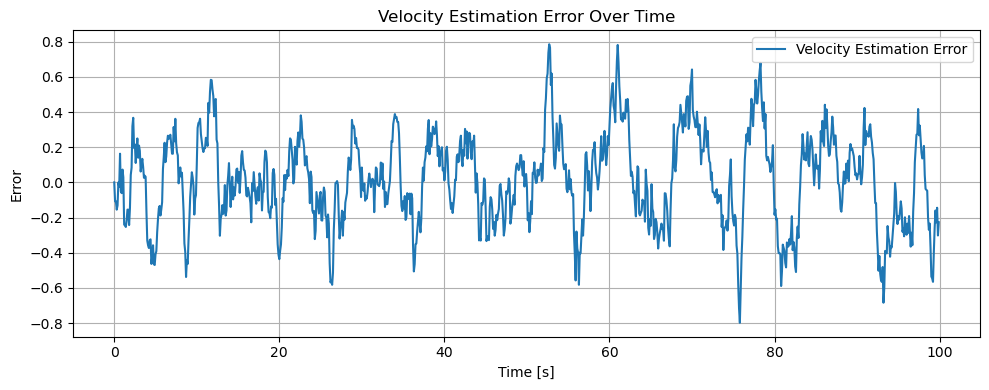

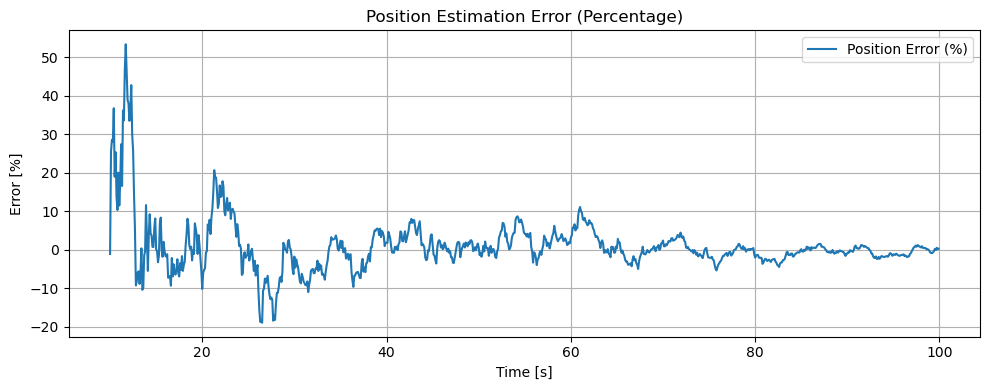

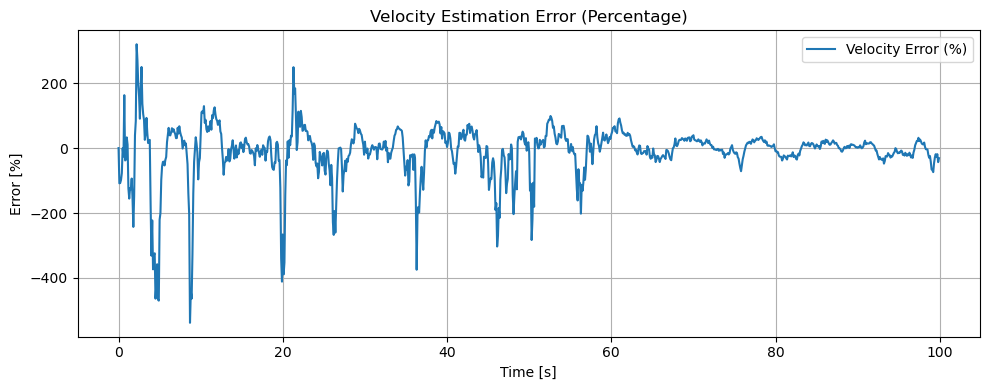

In [38]:
# Compute raw estimation error
pos_error = pos_true - x_est[0]
vel_error = vel_true - x_est[1]

# Position Estimation Error
plt.figure(figsize=(10, 4))
plt.plot(time, pos_error, label='Position Estimation Error')
plt.title('Position Estimation Error Over Time')
plt.xlabel('Time [s]')
plt.ylabel('Error')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Velocity Estimation Error
plt.figure(figsize=(10, 4))
plt.plot(time, vel_error, label='Velocity Estimation Error')
plt.title('Velocity Estimation Error Over Time')
plt.xlabel('Time [s]')
plt.ylabel('Error')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Avoid divide-by-zero issues
pos_true_safe = np.where(pos_true == 0, 1e-6, pos_true)
vel_true_safe = np.where(vel_true == 0, 1e-6, vel_true)

# Percentage error
pos_pct_error = 100 * (pos_true - x_est[0]) / pos_true_safe
vel_pct_error = 100 * (vel_true - x_est[1]) / vel_true_safe

# Position Percentage Error
skip = int(10 / dt)
plt.figure(figsize=(10, 4))
plt.plot(time[skip:], pos_pct_error[skip:], label='Position Error (%)')
plt.title('Position Estimation Error (Percentage)')
plt.xlabel('Time [s]')
plt.ylabel('Error [%]')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()
skip = int(50 / dt)
# Velocity Percentage Error
plt.figure(figsize=(10, 4))
plt.plot(time[:], vel_pct_error[:], label='Velocity Error (%)')
plt.title('Velocity Estimation Error (Percentage)')
plt.xlabel('Time [s]')
plt.ylabel('Error [%]')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

## 5. Reflection
- How does the Kalman filter adapt to the noisy measurements?
- Real-world applications: tracking, sensor fusion, etc.